# Rhythmicity Perturbation using GeneRhythm
This tutorial provides a step-by-step guide on performing inference, analysis, and perturbation of gene expression rhythmicity in a single dataset using GeneRhythm. We demonstrate the diverse capabilities of GeneRhythm by applying it to scRNA-seq data obtained from human PDAC samples.

GeneRhythm leverages user-provided gene expression data by integrating wavelet transformation with deep generative modeling. This approach enables the extraction of frequency-domain features that complement traditional time-domain analyses, allowing for a more comprehensive understanding of gene expression dynamics. 

In [1]:
import subprocess
from Build_graph import *
from Frequency_extract import *
from GCN_VAE import *
from Perturbation import *
from Show_result import *

## Part 1: Data loading, time and frequency information acquisition
### Obtain time information with monocle3
GeneRhythm firstly utilized monocle3 to obtain the trajectory information of single-cell RNA-seq data. trajectory_inference.R is the script to run monocle3. dataset indicated the name of dataset. mtx, barcode and gene indicate the position of the single-cell RNA-seq data.Based on the trajectory information, GeneRhythm can derive time information (Gene expression chagnes on the trajectory pesodu-time path).

In [2]:
dataset = 'PDAC'
mtx = './dataset/PDAC/matrix.mtx'
barcode = './dataset/PDAC/barcodes.csv'
gene  = './dataset/PDAC/features.csv'
subprocess.run(["Rscript", "trajectory_inference.R", dataset, mtx， barcode, gene])

In [3]:
dataset = 'PDAC_Disease'
mtx = './dataset/PDAC_Disease/matrix.mtx'
barcode = './dataset/PDAC_Disease/barcodes.csv'
gene  = './dataset/PDAC_Disease/features.csv'
subprocess.run(["Rscript", "trajectory_inference.R", dataset, mtx， barcode, gene])

In [4]:
dataset = 'PDAC_Control'
mtx = './dataset/PDAC_Control/matrix.mtx'
barcode = './dataset/PDAC_Control/barcodes.csv'
gene  = './dataset/PDAC_Control/features.csv'
subprocess.run(["Rscript", "trajectory_inference.R", dataset, mtx， barcode, gene])

###  Frequency information generation
In this step, we harness the power of wavelet transformation to extract detailed frequency information from the gene expression data. By leveraging the trajectory information obtained from Monocle3—which orders cells along a pseudotime axis—we can capture both the temporal progression and the underlying periodic patterns of gene expression.

Wavelet transformation decomposes the gene expression profiles into various frequency components, enabling us to detect subtle oscillations and rhythmic behaviors that are often not apparent in the time domain alone. This multi-scale analysis helps reveal hidden periodicities and enriches our understanding of gene regulatory mechanisms.

By integrating the frequency-domain features with the temporal trajectory and expression, we achieve a more nuanced analysis. The frequency information complements the time-domain data, enhancing gene clustering. Ultimately, this combined approach provides a comprehensive view of the dynamic changes in gene expression, paving the way for deeper insights into cellular functions and regulatory processes.

In [5]:
trajectory_info = pd.read_csv("PDAC.csv")
mtx = sc.read_mtx(mtx)
mtx = mtx.X.T
barcode = pd.read_csv(barcode,sep=',',index_col=0)
gene  = pd.read_csv(gene,header=0,index_col = 0)
adata = anndata.AnnData(mtx,barcode,gene)
frequency_extract(trajectory_info, adata, dataset)

## Part 2: Model preparation and training
### GCN graph preparation
In this phase, we utilize the Mippie PPI database to extract gene-gene interaction information, thereby constructing the graph structure for our Graph Convolutional Network (GCN). Specifically, the database provides gene interaction data that has been validated by both experimental evidence and computational predictions. We treat these interactions as edges in the graph, with each gene represented as a node. By integrating this biologically informed network structure with the previously obtained gene expression and frequency information, the GCN model is better equipped to capture the regulatory relationships and functional synergies between genes. This integration ultimately enhances the accuracy and interpretability of gene clustering and biomarker identification during model training.

In [6]:
gene_id = gene.index.to_list()
pd.Series(gene_id).to_csv(
    'PDAC.txt',
    index=False,
    header=False
)
!java -jar HIPPIE_NC.jar -i=./PDAC.txt -t=e -o=out_PDAC.txt -s=0.5
graph_df = pd.read_csv('out_PDAC.txt', sep='\t', header=None)
build_graph_mouse(graph_df,gene_info)

### Modle training
In this stage, the model is trained using time, frequency, and expression data, along with the previously constructed graph. This integration allows the model to learn a comprehensive latent embedding that encapsulates the intricate relationships among genes. Once the model has been trained, we apply the Leiden algorithm to the latent space to identify gene clusters. These clusters represent groups of genes with similar expression dynamics and regulatory patterns, providing a valuable basis for further biological insights and downstream analysis.

In [7]:
GeneRhythm_Model(input_data = 'PDAC.npy',graph='graph_index.npy',sc_data = adata)


____________________________
Start Training VAE...
torch.Size([1976, 250])
Epochs: 1, AvgLoss: 61.1784
torch.Size([1976, 250])
Epochs: 2, AvgLoss: 61.0733
torch.Size([1976, 250])
Epochs: 3, AvgLoss: 60.9595
torch.Size([1976, 250])
Epochs: 4, AvgLoss: 60.8456
torch.Size([1976, 250])
Epochs: 5, AvgLoss: 60.7324
torch.Size([1976, 250])
Epochs: 6, AvgLoss: 60.6032
torch.Size([1976, 250])
Epochs: 7, AvgLoss: 60.4694
torch.Size([1976, 250])
Epochs: 8, AvgLoss: 60.3244
torch.Size([1976, 250])
Epochs: 9, AvgLoss: 60.1658
torch.Size([1976, 250])
Epochs: 10, AvgLoss: 59.9907
torch.Size([1976, 250])
Epochs: 11, AvgLoss: 59.8120
torch.Size([1976, 250])
Epochs: 12, AvgLoss: 59.6022
torch.Size([1976, 250])
Epochs: 13, AvgLoss: 59.3655
torch.Size([1976, 250])
Epochs: 14, AvgLoss: 59.0947
torch.Size([1976, 250])
Epochs: 15, AvgLoss: 58.8603
torch.Size([1976, 250])
Epochs: 16, AvgLoss: 58.5570
torch.Size([1976, 250])
Epochs: 17, AvgLoss: 58.2088
torch.Size([1976, 250])
Epochs: 18, AvgLoss: 57.8403
tor

## Part 3: Perturbation

### 1. Gene perturbation  
Perform in silico perturbation of individual genes to evaluate their causal impact on global gene expression programs. For each perturbed gene, quantify downstream effects on other genes and identify significantly affected genes based on the strength and consistency of the response. Save to gene_perturbation.csv file.



In [8]:
Gene_Perturbation('PDAC_Control.csv','PDAC_Disease.csv','./dataset/PDAC_Control','./dataset/PDAC_Disease',graph = graph)

### 2. Drug-target perturbation  
Perturb gene sets corresponding to known drug targets to simulate pharmacological interventions. Analyze how drug-target perturbations propagate through the gene network and identify genes and regulatory programs that are most sensitive to drug-induced effects. Save to drug_perturbation.csv

In [9]:
Pathway_Drug_Perturbation('PDAC_Control.csv','PDAC_Disease.csv','./dataset/PDAC_Control','./dataset/PDAC_Disease', term_profile_path='./dataset/cmap_drug_target_genes.npy',out_csv='drug_perturbation.csv',graph = graph)

### 3. Pathway-level perturbation  
Perturb entire biological pathways by jointly modulating all member genes. Measure coordinated downstream responses to assess pathway-level regulatory influence and enable systematic comparison of pathway perturbation effects across conditions. Save to pathway_perturbation.csv.


In [10]:
Pathway_Drug_Perturbation('PDAC_Control.csv','PDAC_Disease.csv','./dataset/PDAC_Control','./dataset/PDAC_Disease', term_profile_path='./dataset/gesa_pathways.npy',out_csv='pathway_perturbation.csv',graph = graph)

## Part 4: Survival Analysis
To assess the clinical relevance of genes identified by the perturbation analysis, we performed survival analysis using bulk transcriptomic data with matched patient outcomes. Patients were stratified into high- and low-risk groups based on quartiles of a composite gene expression score, and survival differences were evaluated using Kaplan–Meier analysis and the log-rank test.

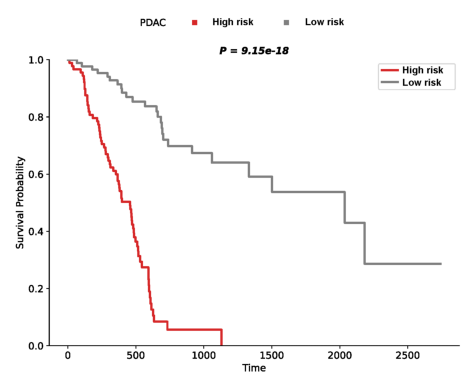

In [11]:
import pandas as pd
genes = pd.read_csv("gene_perturbation.csv", usecols=[0]).iloc[:, 0].tolist()
Survival('./dataset/PAAD_processed_bulk.csv'，genes)